In [3]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import json
from simulations import run_sim

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
def plot_convergence(result, title):
    running_accuracies, convergence_metrics, params = result

    plt.figure(figsize=(12, 6))

    for run_number, run_acc in enumerate(running_accuracies, start=1):
        plt.plot(range(1, params['agents'] + 1), run_acc, label=f'Run {run_number}')

    plt.axhline(y=1.0, color='green', linestyle='--', linewidth=2)
    plt.axhline(y=0.0, color='red', linestyle='--', linewidth=2)

    plt.title(title)
    plt.xlabel('Agent Index (t)')
    plt.ylabel('Running Proportion of Correct Actions')
    plt.ylim(-0.05, 1.05)
    plt.grid(alpha=0.3)

    if params['runs'] <= 10:
        plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title='Simulation Run')

    plt.tight_layout()
    plt.show()


def summarise_convergence_metrics(result):
    rows = []
    for run_number, (converged, success, lock_in_index, final_accuracy) in enumerate(result.convergence_metrics, start=1):
        if converged is True and success is True:
            status = 'converged accurately'
        elif converged is True and success is False:
            status = 'converged inaccurately'
        elif converged is False:
            status = 'did not converge'
        else:
            status = 'unknown'

        rows.append((run_number, status, lock_in_index, final_accuracy))

    for run_number, status, lock_in_index, final_accuracy in rows:
        print(f"Run {run_number}: {status} | lock_in_index={lock_in_index} | final_accuracy={final_accuracy:.4f}")

    converged_runs = [
        run_number
        for run_number, status, _, _ in rows
        if status == 'converged accurately' or status == 'converged inaccurately'
    ]
    lock_in_indices = [
        lock_in_index
        for _, status, lock_in_index, _ in rows
        if lock_in_index is not None
    ]

    print(f"Converged runs: {converged_runs}")
    print(f"Lock-in indices: {lock_in_indices}")



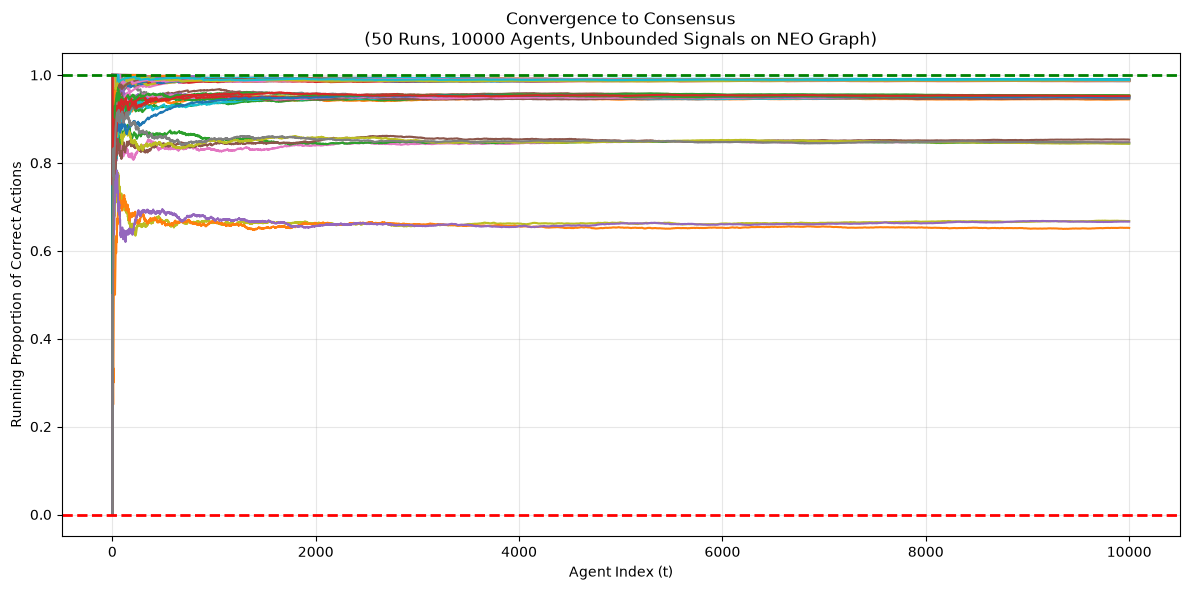

Run 1: did not converge | lock_in_index=None | final_accuracy=0.9861
Run 2: did not converge | lock_in_index=None | final_accuracy=0.9445
Run 3: did not converge | lock_in_index=None | final_accuracy=0.9470
Run 4: did not converge | lock_in_index=None | final_accuracy=0.9860
Run 5: did not converge | lock_in_index=None | final_accuracy=0.9886
Run 6: did not converge | lock_in_index=None | final_accuracy=0.9494
Run 7: did not converge | lock_in_index=None | final_accuracy=0.8473
Run 8: did not converge | lock_in_index=None | final_accuracy=0.9524
Run 9: did not converge | lock_in_index=None | final_accuracy=0.6677
Run 10: did not converge | lock_in_index=None | final_accuracy=0.9469
Run 11: did not converge | lock_in_index=None | final_accuracy=0.9503
Run 12: did not converge | lock_in_index=None | final_accuracy=0.9875
Run 13: did not converge | lock_in_index=None | final_accuracy=0.8443
Run 14: did not converge | lock_in_index=None | final_accuracy=0.9899
Run 15: did not converge | lo

In [5]:
# Theorem 1.
result = run_sim('NEO', 'unbounded', k=5, runs=50, agents=10000, seed=123)

title = f"Convergence to Consensus\n({result.params['runs']} Runs, {result.params['agents']} Agents, {result.params['signal_type'].title()} Signals on {result.params['graph_type']} Graph)"
plot_convergence(result, title)
summarise_convergence_metrics(result)


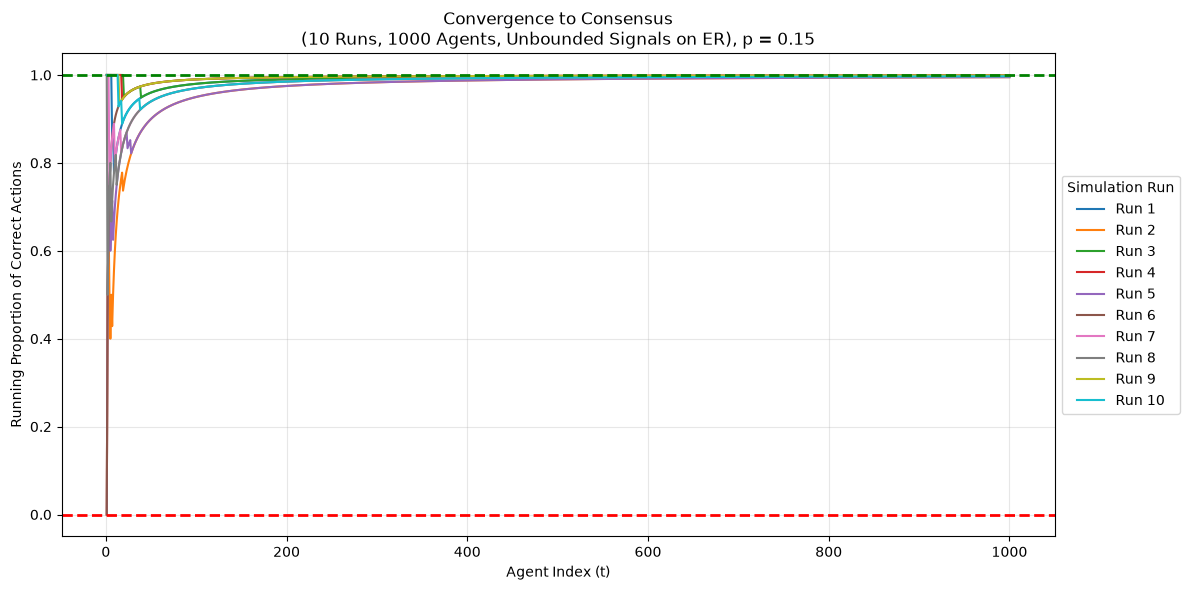

Run 1: converged accurately | lock_in_index=9 | final_accuracy=0.9980
Run 2: converged accurately | lock_in_index=19 | final_accuracy=0.9950
Run 3: converged accurately | lock_in_index=39 | final_accuracy=0.9980
Run 4: converged accurately | lock_in_index=18 | final_accuracy=0.9990
Run 5: converged accurately | lock_in_index=28 | final_accuracy=0.9950
Run 6: converged accurately | lock_in_index=1 | final_accuracy=0.9990
Run 7: converged accurately | lock_in_index=17 | final_accuracy=0.9970
Run 8: converged accurately | lock_in_index=12 | final_accuracy=0.9970
Run 9: converged accurately | lock_in_index=15 | final_accuracy=0.9990
Run 10: converged accurately | lock_in_index=38 | final_accuracy=0.9970
Converged runs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Lock-in indices: [9, 19, 39, 18, 28, 1, 17, 12, 15, 38]


In [6]:
# Theorem 2.
p_val = 0.15
result = run_sim('ER', 'unbounded', runs=10, agents=1000, p=p_val, seed=123)

title = f"Convergence to Consensus\n({result.params['runs']} Runs, {result.params['agents']} Agents, {result.params['signal_type'].title()} Signals on {result.params['graph_type']}), p = {p_val:.2f}"
plot_convergence(result, title)
summarise_convergence_metrics(result)


In [7]:
from simulations import run_sim

print("Hunting for a false cascade seed...")

p_val = 0.8
agents_to_test = 1000

for test_seed in range(1, 10000):
    # Run a single simulation per seed
    result = run_sim('ER', 'unbounded', runs=1, agents=agents_to_test, p=p_val, seed=test_seed)
    
    # Extract the metrics for this single run
    converged, success, lock_time, final_accuracy = result.convergence_metrics[0]
    
    # If the network locked in, but guessed WRONG
    if converged is True and success is False:
        print(f"Got one! Use seed={test_seed}")
        print(f"The false cascade locked in at agent {lock_time}.")
        print(f"The final accuracy was {final_accuracy:.4f}.")
        break

Hunting for a false cascade seed...


Got one! Use seed=24
The false cascade locked in at agent 8.
The final accuracy was 0.0030.


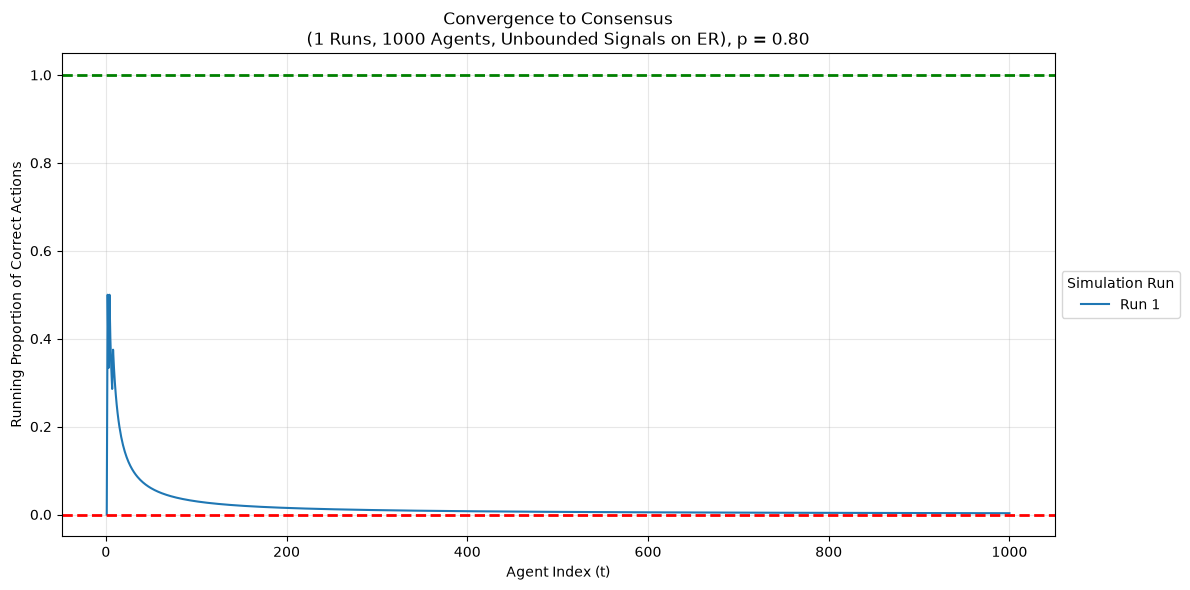

Run 1: converged inaccurately | lock_in_index=8 | final_accuracy=0.0030
Converged runs: [1]
Lock-in indices: [8]


In [8]:
# Theorem 2 - issue.

p_val = 0.8
result = run_sim('ER', 'unbounded', runs=1, agents=1000, p=p_val, seed=24)

title = f"Convergence to Consensus\n({result.params['runs']} Runs, {result.params['agents']} Agents, {result.params['signal_type'].title()} Signals on {result.params['graph_type']}), p = {p_val:.2f}"
plot_convergence(result, title)
summarise_convergence_metrics(result)

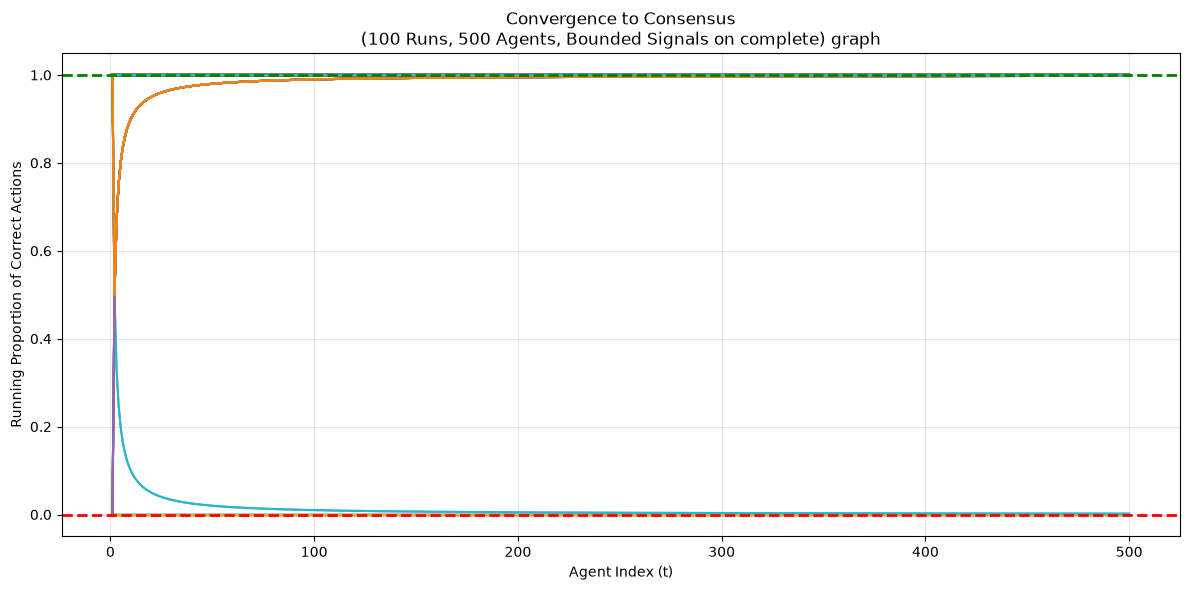

Run 1: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 2: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 3: converged accurately | lock_in_index=2 | final_accuracy=0.9980
Run 4: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 5: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 6: converged accurately | lock_in_index=2 | final_accuracy=0.9980
Run 7: converged inaccurately | lock_in_index=2 | final_accuracy=0.0020
Run 8: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 9: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 10: converged inaccurately | lock_in_index=0 | final_accuracy=0.0000
Run 11: converged accurately | lock_in_index=1 | final_accuracy=0.9980
Run 12: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 13: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 14: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 15: con

In [9]:
# Theorem 3i.
result = run_sim('complete', 'bounded', runs=100, agents=500, q=0.8, seed=123)

title = f"Convergence to Consensus\n({result.params['runs']} Runs, {result.params['agents']} Agents, {result.params['signal_type'].title()} Signals on {result.params['graph_type']}) graph"
plot_convergence(result, title)
summarise_convergence_metrics(result)


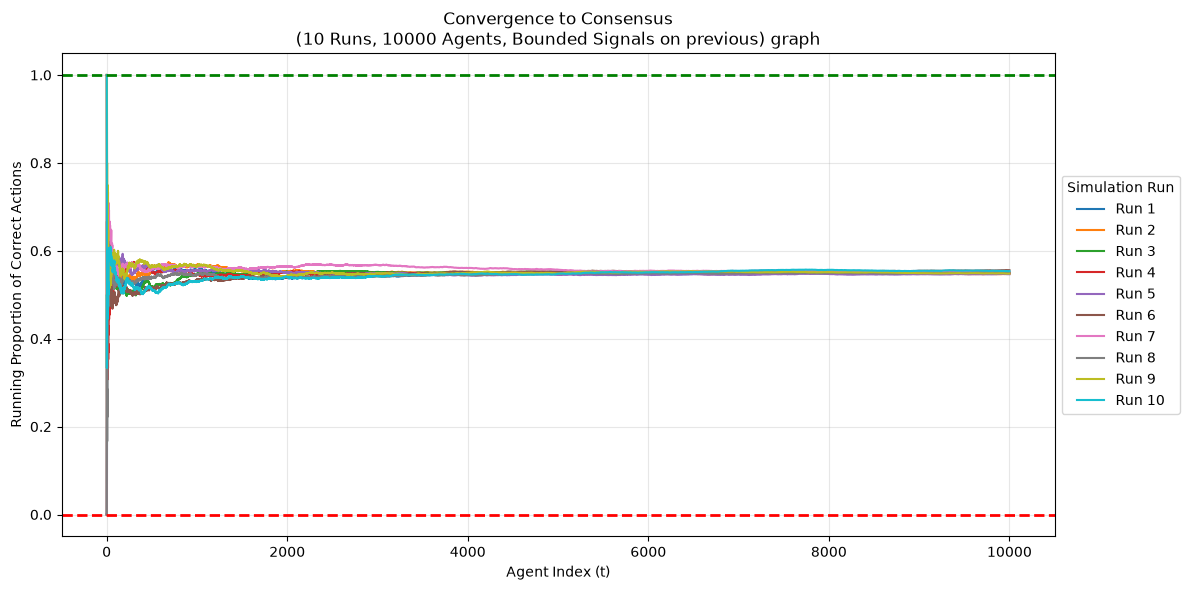

Run 1: did not converge | lock_in_index=None | final_accuracy=0.5493
Run 2: did not converge | lock_in_index=None | final_accuracy=0.5475
Run 3: did not converge | lock_in_index=None | final_accuracy=0.5504
Run 4: did not converge | lock_in_index=None | final_accuracy=0.5491
Run 5: did not converge | lock_in_index=None | final_accuracy=0.5467
Run 6: did not converge | lock_in_index=None | final_accuracy=0.5559
Run 7: did not converge | lock_in_index=None | final_accuracy=0.5512
Run 8: did not converge | lock_in_index=None | final_accuracy=0.5511
Run 9: did not converge | lock_in_index=None | final_accuracy=0.5482
Run 10: did not converge | lock_in_index=None | final_accuracy=0.5539
Converged runs: []
Lock-in indices: []


In [10]:
# Theorem 3ii.
result = run_sim('previous', 'bounded', runs=10, agents=10000, seed=123, q=0.4)

title = f"Convergence to Consensus\n({result.params['runs']} Runs, {result.params['agents']} Agents, {result.params['signal_type'].title()} Signals on {result.params['graph_type']}) graph"
plot_convergence(result, title)
summarise_convergence_metrics(result)


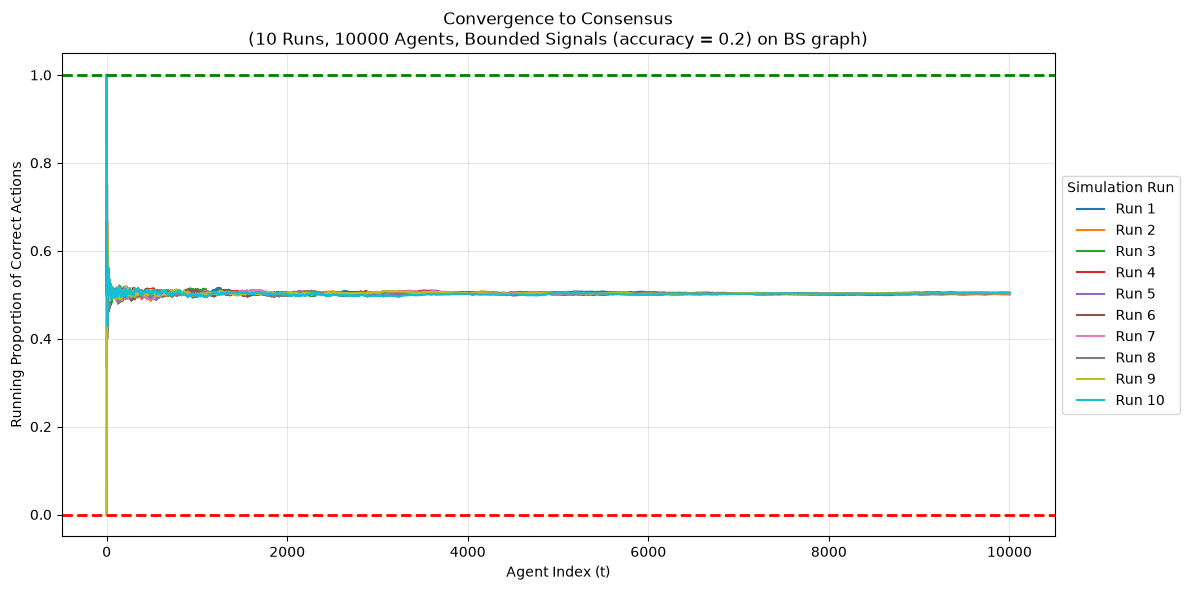

Run 1: did not converge | lock_in_index=None | final_accuracy=0.5041
Run 2: did not converge | lock_in_index=None | final_accuracy=0.5032
Run 3: did not converge | lock_in_index=None | final_accuracy=0.5010
Run 4: did not converge | lock_in_index=None | final_accuracy=0.5012
Run 5: did not converge | lock_in_index=None | final_accuracy=0.5045
Run 6: did not converge | lock_in_index=None | final_accuracy=0.5025
Run 7: did not converge | lock_in_index=None | final_accuracy=0.5027
Run 8: did not converge | lock_in_index=None | final_accuracy=0.5041
Run 9: did not converge | lock_in_index=None | final_accuracy=0.5030
Run 10: did not converge | lock_in_index=None | final_accuracy=0.5048
Converged runs: []
Lock-in indices: []


In [11]:
# Theorem 3iii.
result = run_sim('BS', 'bounded', runs=10, agents=10000, sample=100, seed=123, q = 0.2)

title = f"Convergence to Consensus\n({result.params['runs']} Runs, {result.params['agents']} Agents, {result.params['signal_type'].title()} Signals (accuracy = {result.params['q']}) on {result.params['graph_type']} graph)"
plot_convergence(result, title)
summarise_convergence_metrics(result)


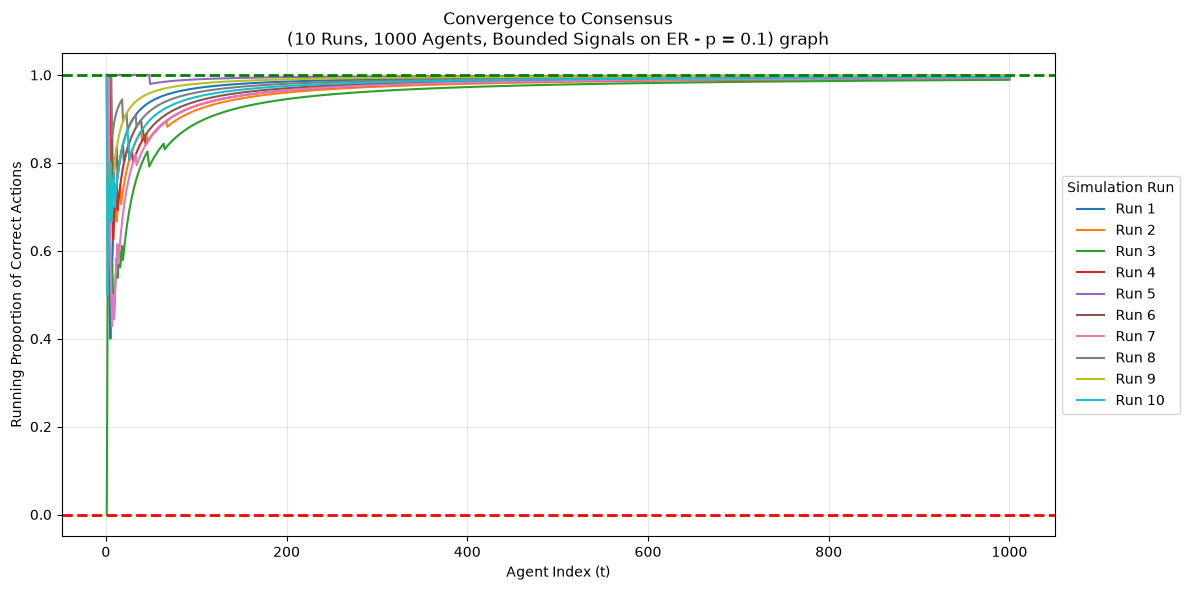

Run 1: converged accurately | lock_in_index=5 | final_accuracy=0.9970
Run 2: converged accurately | lock_in_index=68 | final_accuracy=0.9920
Run 3: converged accurately | lock_in_index=65 | final_accuracy=0.9890
Run 4: converged accurately | lock_in_index=44 | final_accuracy=0.9930
Run 5: converged accurately | lock_in_index=49 | final_accuracy=0.9990
Run 6: converged accurately | lock_in_index=42 | final_accuracy=0.9940
Run 7: converged accurately | lock_in_index=34 | final_accuracy=0.9930
Run 8: converged accurately | lock_in_index=34 | final_accuracy=0.9960
Run 9: converged accurately | lock_in_index=6 | final_accuracy=0.9980
Run 10: converged accurately | lock_in_index=26 | final_accuracy=0.9950
Converged runs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Lock-in indices: [5, 68, 65, 44, 49, 42, 34, 34, 6, 26]


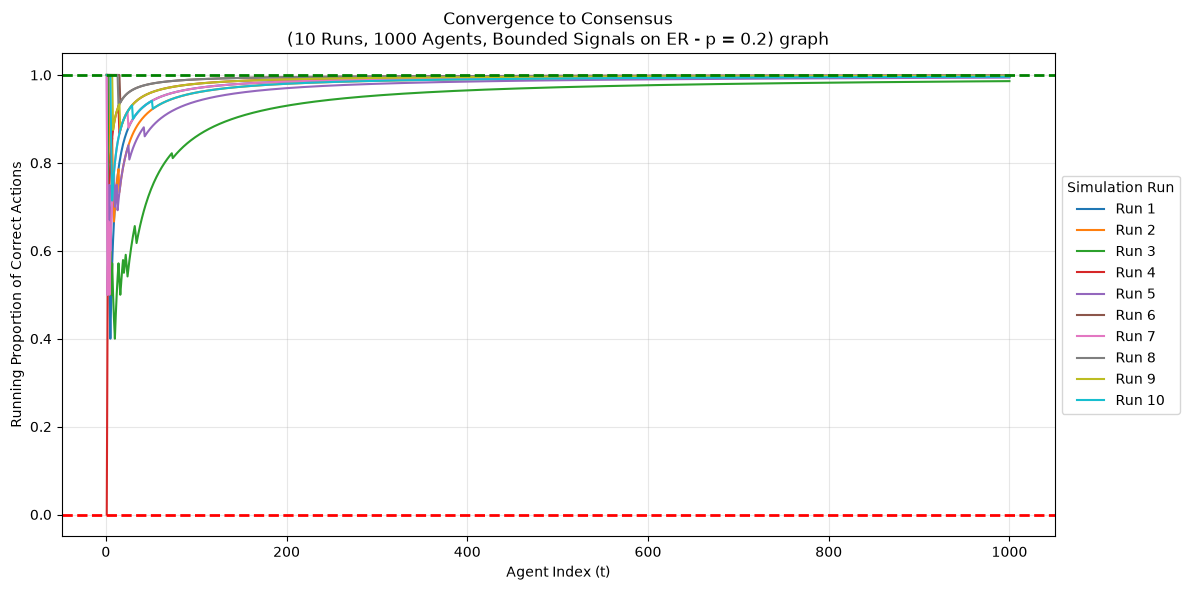

Run 1: converged accurately | lock_in_index=5 | final_accuracy=0.9970
Run 2: converged accurately | lock_in_index=15 | final_accuracy=0.9960
Run 3: converged accurately | lock_in_index=74 | final_accuracy=0.9860
Run 4: converged accurately | lock_in_index=15 | final_accuracy=0.9980
Run 5: converged accurately | lock_in_index=43 | final_accuracy=0.9940
Run 6: converged accurately | lock_in_index=16 | final_accuracy=0.9990
Run 7: converged accurately | lock_in_index=25 | final_accuracy=0.9970
Run 8: converged accurately | lock_in_index=14 | final_accuracy=0.9990
Run 9: converged accurately | lock_in_index=16 | final_accuracy=0.9980
Run 10: converged accurately | lock_in_index=52 | final_accuracy=0.9960
Converged runs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Lock-in indices: [5, 15, 74, 15, 43, 16, 25, 14, 16, 52]


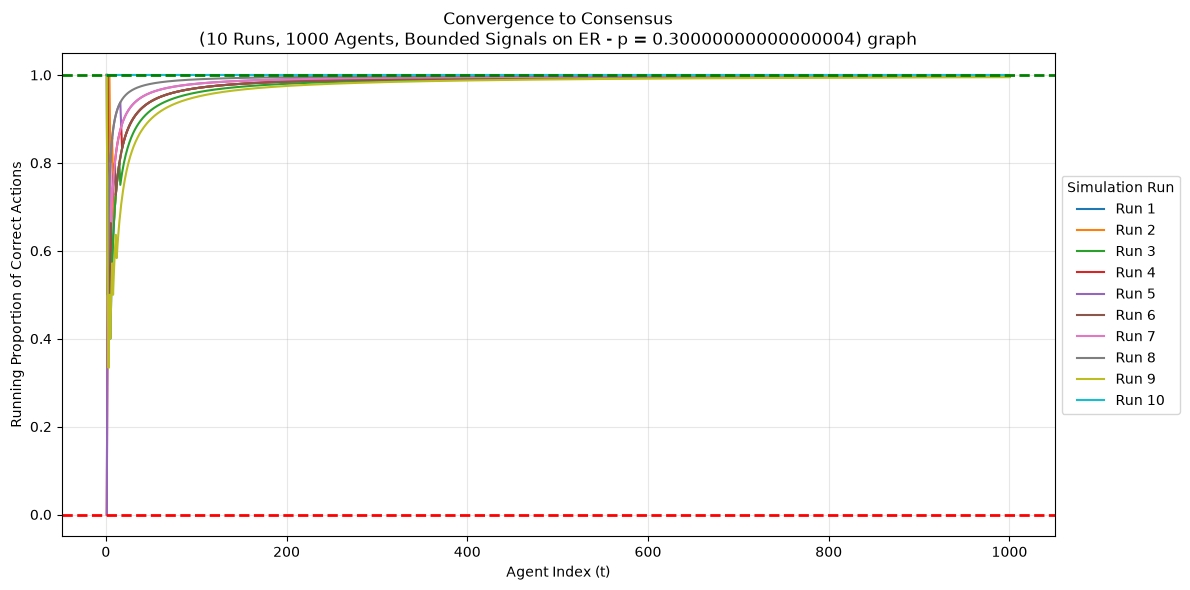

Run 1: converged accurately | lock_in_index=5 | final_accuracy=0.9970
Run 2: converged accurately | lock_in_index=9 | final_accuracy=0.9970
Run 3: converged accurately | lock_in_index=16 | final_accuracy=0.9960
Run 4: converged accurately | lock_in_index=18 | final_accuracy=0.9970
Run 5: converged accurately | lock_in_index=17 | final_accuracy=0.9980
Run 6: converged accurately | lock_in_index=11 | final_accuracy=0.9970
Run 7: converged accurately | lock_in_index=6 | final_accuracy=0.9980
Run 8: converged accurately | lock_in_index=2 | final_accuracy=0.9990
Run 9: converged accurately | lock_in_index=12 | final_accuracy=0.9950
Run 10: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Converged runs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Lock-in indices: [5, 9, 16, 18, 17, 11, 6, 2, 12, 0]


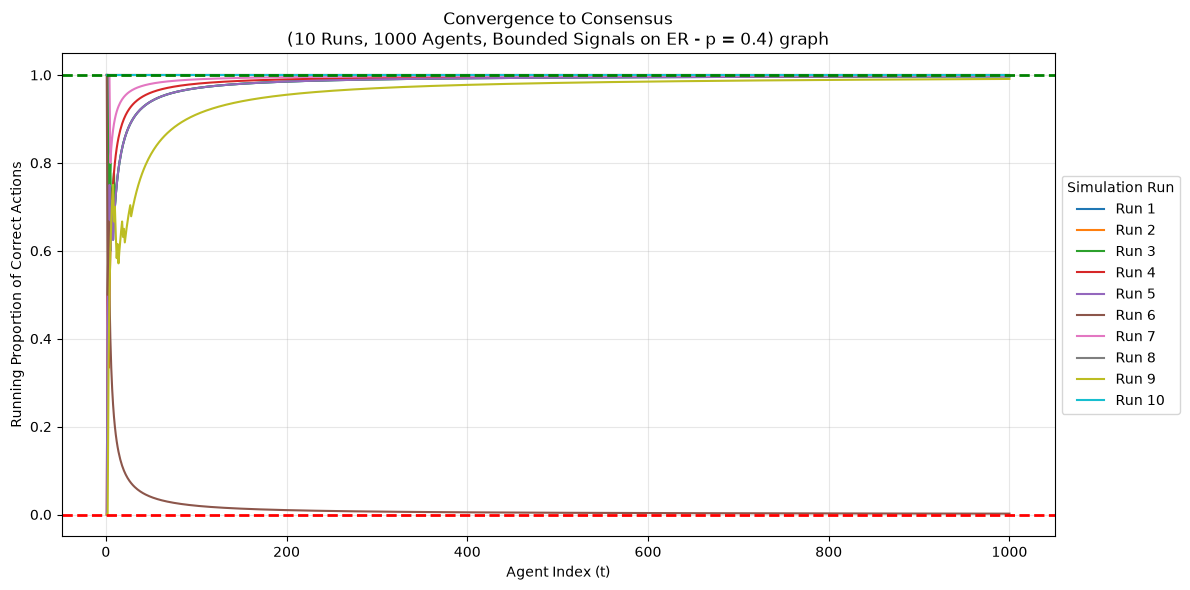

Run 1: converged accurately | lock_in_index=8 | final_accuracy=0.9970
Run 2: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 3: converged accurately | lock_in_index=10 | final_accuracy=0.9970
Run 4: converged accurately | lock_in_index=3 | final_accuracy=0.9980
Run 5: converged accurately | lock_in_index=8 | final_accuracy=0.9970
Run 6: converged inaccurately | lock_in_index=3 | final_accuracy=0.0020
Run 7: converged accurately | lock_in_index=5 | final_accuracy=0.9990
Run 8: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 9: converged accurately | lock_in_index=28 | final_accuracy=0.9910
Run 10: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Converged runs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Lock-in indices: [8, 0, 10, 3, 8, 3, 5, 0, 28, 0]


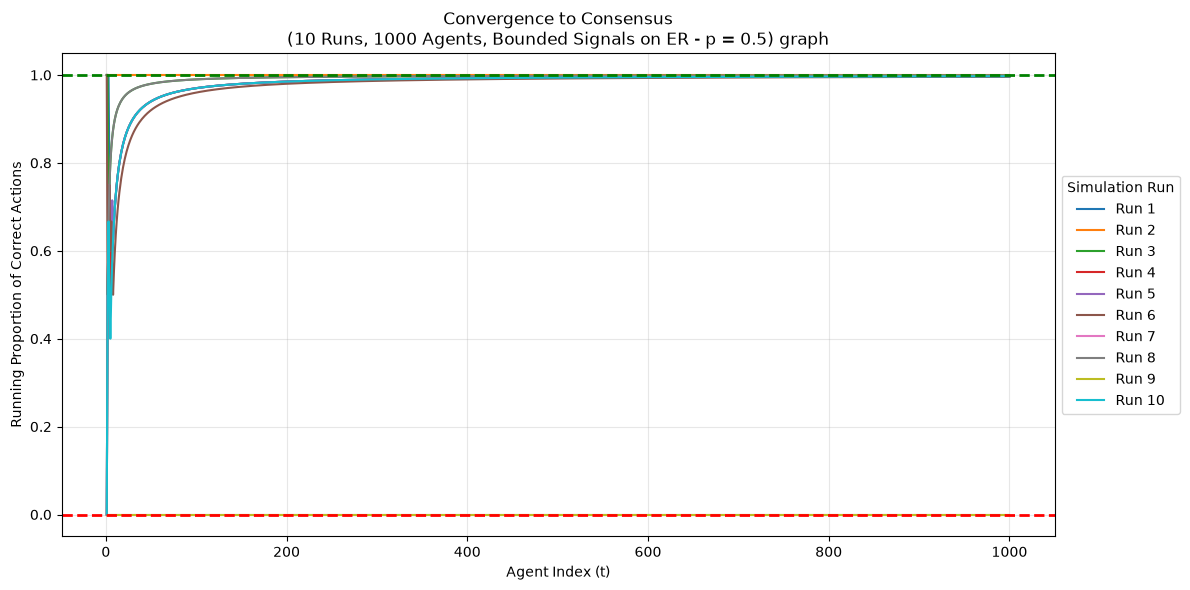

Run 1: converged accurately | lock_in_index=8 | final_accuracy=0.9970
Run 2: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 3: converged accurately | lock_in_index=3 | final_accuracy=0.9990
Run 4: converged accurately | lock_in_index=6 | final_accuracy=0.9970
Run 5: converged accurately | lock_in_index=8 | final_accuracy=0.9970
Run 6: converged accurately | lock_in_index=8 | final_accuracy=0.9960
Run 7: converged inaccurately | lock_in_index=0 | final_accuracy=0.0000
Run 8: converged accurately | lock_in_index=1 | final_accuracy=0.9990
Run 9: converged inaccurately | lock_in_index=0 | final_accuracy=0.0000
Run 10: converged accurately | lock_in_index=5 | final_accuracy=0.9970
Converged runs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Lock-in indices: [8, 0, 3, 6, 8, 8, 0, 1, 0, 5]


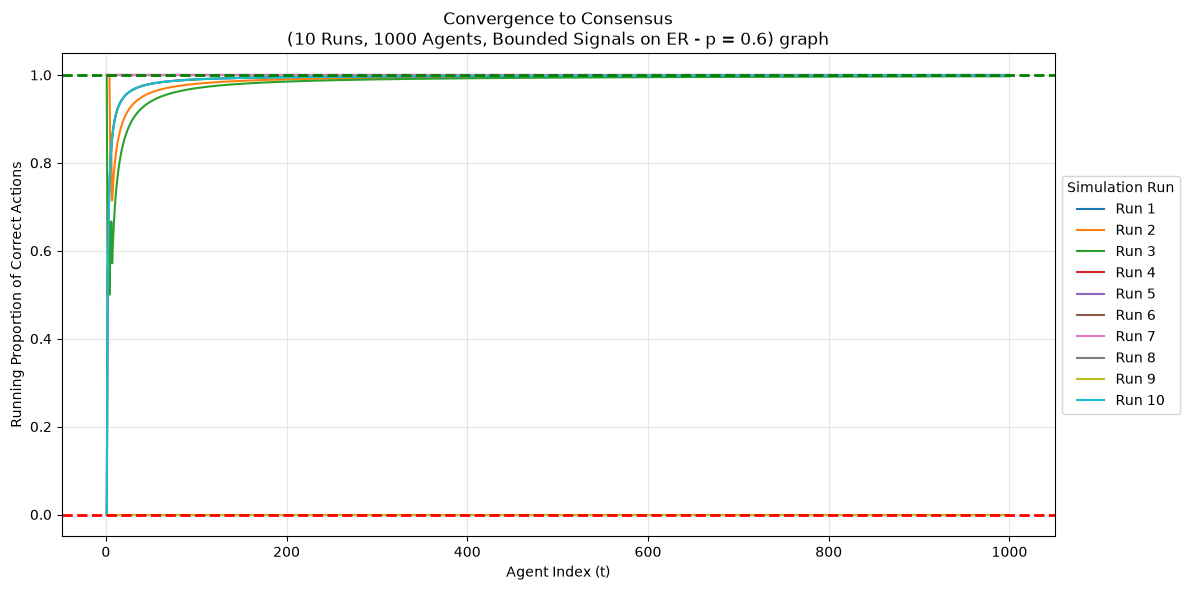

Run 1: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 2: converged accurately | lock_in_index=7 | final_accuracy=0.9980
Run 3: converged accurately | lock_in_index=7 | final_accuracy=0.9970
Run 4: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 5: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 6: converged accurately | lock_in_index=1 | final_accuracy=0.9990
Run 7: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 8: converged accurately | lock_in_index=1 | final_accuracy=0.9990
Run 9: converged inaccurately | lock_in_index=0 | final_accuracy=0.0000
Run 10: converged accurately | lock_in_index=1 | final_accuracy=0.9990
Converged runs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Lock-in indices: [0, 7, 7, 0, 0, 1, 0, 1, 0, 1]


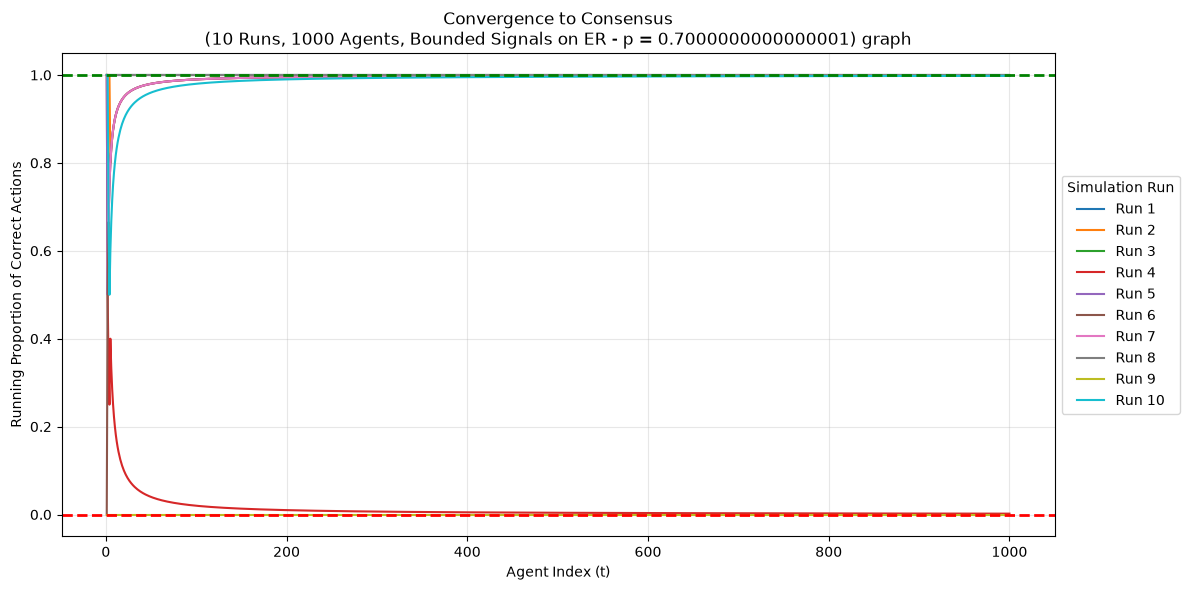

Run 1: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 2: converged accurately | lock_in_index=5 | final_accuracy=0.9990
Run 3: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 4: converged inaccurately | lock_in_index=5 | final_accuracy=0.0020
Run 5: converged accurately | lock_in_index=2 | final_accuracy=0.9990
Run 6: converged accurately | lock_in_index=1 | final_accuracy=0.9990
Run 7: converged accurately | lock_in_index=3 | final_accuracy=0.9990
Run 8: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 9: converged inaccurately | lock_in_index=0 | final_accuracy=0.0000
Run 10: converged accurately | lock_in_index=4 | final_accuracy=0.9980
Converged runs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Lock-in indices: [0, 5, 0, 5, 2, 1, 3, 0, 0, 4]


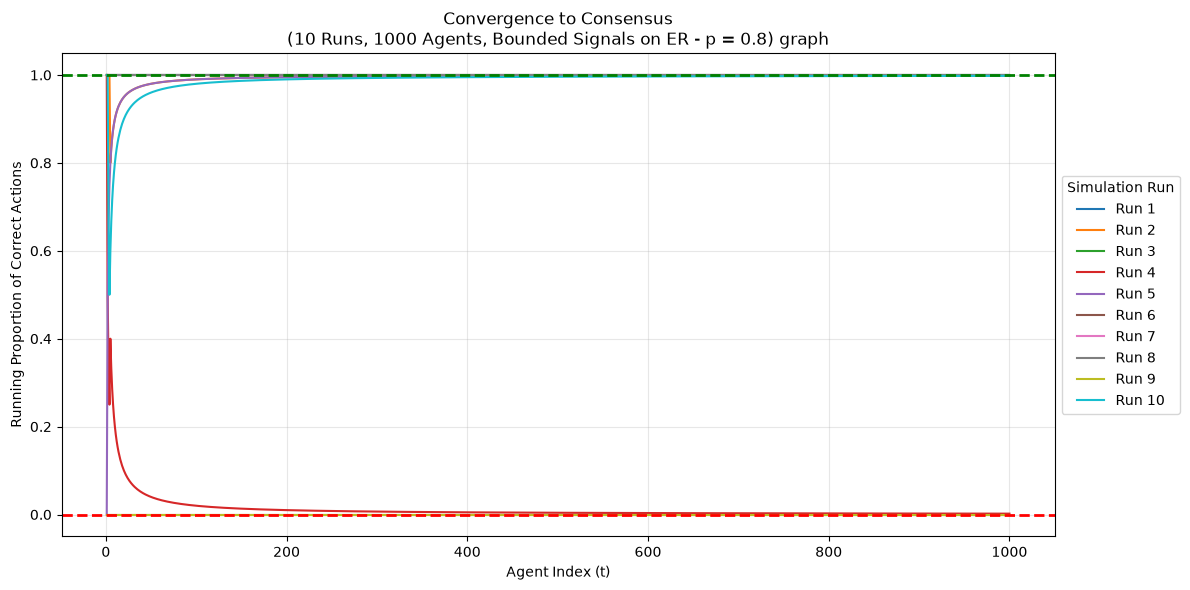

Run 1: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 2: converged accurately | lock_in_index=5 | final_accuracy=0.9990
Run 3: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 4: converged inaccurately | lock_in_index=5 | final_accuracy=0.0020
Run 5: converged accurately | lock_in_index=1 | final_accuracy=0.9990
Run 6: converged inaccurately | lock_in_index=0 | final_accuracy=0.0000
Run 7: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 8: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 9: converged inaccurately | lock_in_index=0 | final_accuracy=0.0000
Run 10: converged accurately | lock_in_index=4 | final_accuracy=0.9980
Converged runs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Lock-in indices: [0, 5, 0, 5, 1, 0, 0, 0, 0, 4]


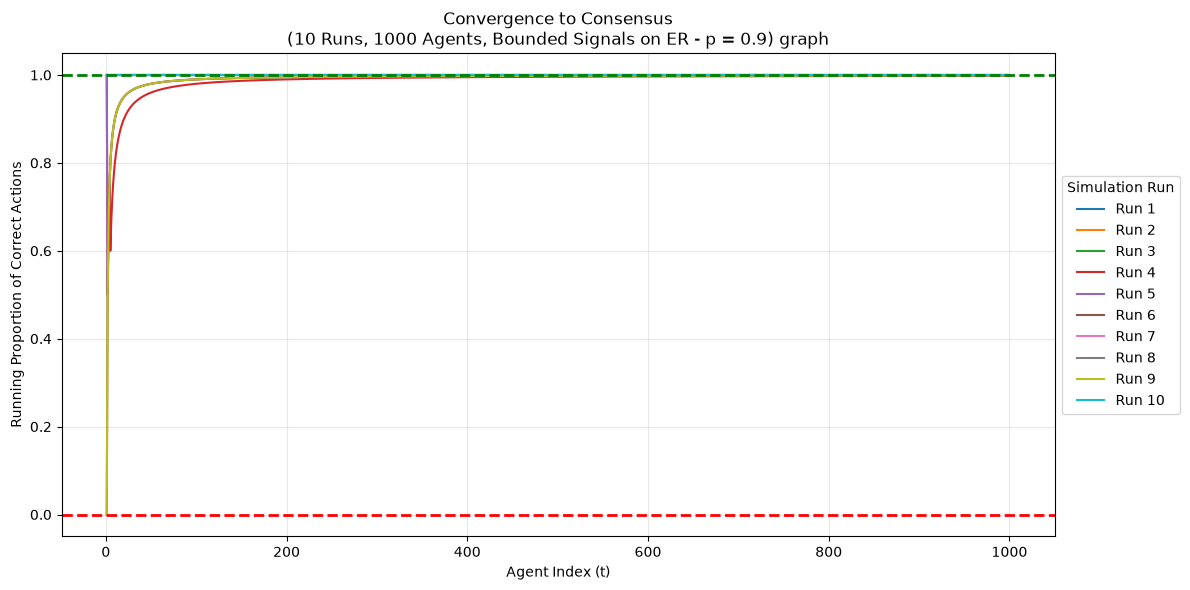

Run 1: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 2: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 3: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 4: converged accurately | lock_in_index=5 | final_accuracy=0.9980
Run 5: converged accurately | lock_in_index=2 | final_accuracy=0.9990
Run 6: converged accurately | lock_in_index=1 | final_accuracy=0.9990
Run 7: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 8: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 9: converged accurately | lock_in_index=1 | final_accuracy=0.9990
Run 10: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Converged runs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Lock-in indices: [0, 0, 0, 5, 2, 1, 0, 0, 1, 0]


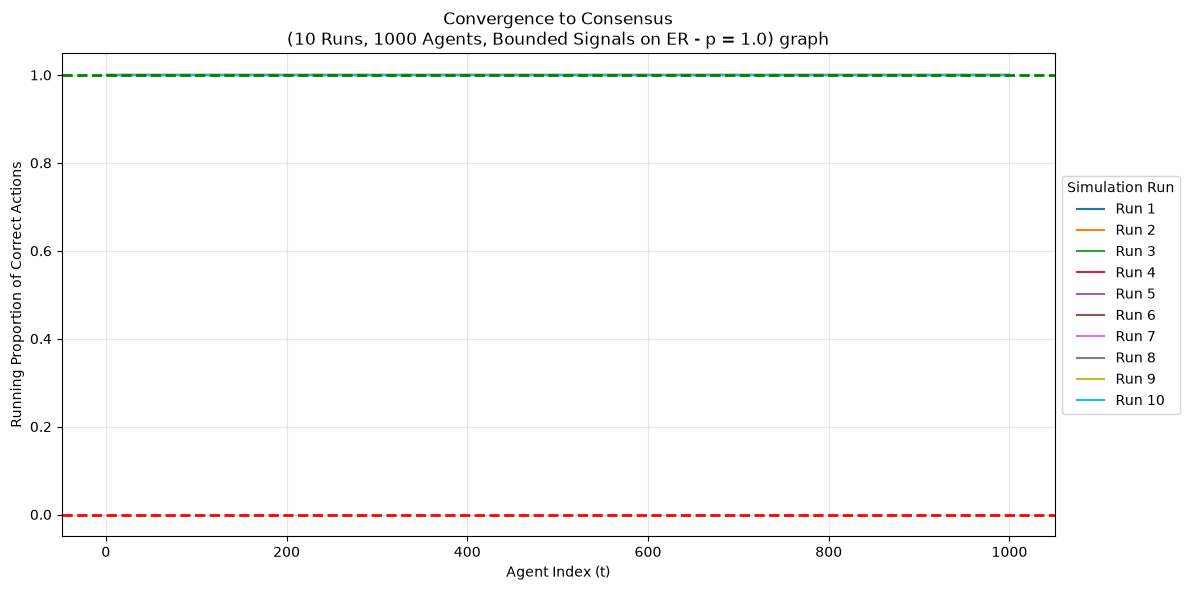

Run 1: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 2: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 3: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 4: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 5: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 6: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 7: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 8: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 9: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Run 10: converged accurately | lock_in_index=0 | final_accuracy=1.0000
Converged runs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Lock-in indices: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [12]:
# ER + bounded exploration

for p in np.linspace(0.1, 1, 10):
    result = run_sim('ER', 'bounded', runs = 10, agents=1000, p=p, seed=123, q=0.75)
    title = f"Convergence to Consensus\n({result.params['runs']} Runs, {result.params['agents']} Agents, {result.params['signal_type'].title()} Signals on {result.params['graph_type']} - p = {p}) graph"
    plot_convergence(result, title)
    summarise_convergence_metrics(result)


In [14]:
import time
start_time = time.time()

runs = 100
agents = 1000
p = 0.5
k = 50
sample = 100
planned_loops = 19
planned_runs_per_loop = 1000
result = run_sim('complete', 'unbounded', runs=runs, agents=agents, seed=42)
end_time = time.time()

time_per_run = (end_time - start_time) / runs
total_planned_runs = planned_loops * planned_runs_per_loop

print(f"Time per run: {time_per_run:.4f} seconds.")
print(f"Estimated time for {total_planned_runs} runs (Overnight Total): {(time_per_run * total_planned_runs) / 3600:.2f} hours.")

Time per run: 1.0961 seconds.
Estimated time for 19000 runs (Overnight Total): 5.79 hours.
